In [1]:
import os
os.chdir('/nfs/mary/Users/eelse/scripts/jupyter')

%matplotlib inline
import xarray as xr
import cartopy.feature
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import cmcrameri.cm as cmc
from matplotlib.colors import BoundaryNorm, TwoSlopeNorm, LinearSegmentedColormap, ListedColormap, Normalize
import matplotlib as mpl

import regionmask
import geopandas as gpd
import pandas as pd
regionmask.__version__
#Yvans
import mw_protocol.plotting as plotting
import mw_protocol.saving as saving
import mw_protocol.glac1d_toolbox as tb
import pylaeoclim_leeds.util_hadcm3 as util

#Mine
import mymodules.myfunc as mf 


colores = {'0':'tab:blue', '1':'tab:orange', '2':'tab:green', '3':'tab:red', '4':'tab:purple', '5':'tab:brown', '6':'tab:pink',
         '7':'tab:olive', '8':'tab:cyan'}

In [2]:
#Load Data
#Land Sea Mask
#landmask
with mf.Timer('Land sea mask loader'):
    data_folder = f"/nfs/annie/eeymr/work/data/publication/ROME2022_paleoceanography_oscillations"
    ds_lsm = xr.open_dataset(f"{data_folder}/lgm_inputs/temev.qrparm.omask.nc")
    lsm = ds_lsm.lsm
    lon_lsm, lat_lsm = ds_lsm.longitude.values, ds_lsm.latitude.values
    lon_lsm_b, lat_lsm_b = tb.create_coordinate_edges(lon_lsm), lat_lsm
#lsm = ds_lsm.lsm
#ds_lsm

#Regions
ds_dye = xr.open_dataset('myintermediates/dyestuff_modelpaper/dye_regions_norm.nc')
dyen = list(ds_dye.data_vars)

#Regionfluxes
gdf = pd.read_pickle('myintermediates/gdf_regions.pkl')

# Batchelor Ice sheet reconstruction
#LGM Shapefile
# Path to your shapefile (.shp)
shapefile_path = '/nfs/mary/Users/eelse/work/ice_reconstruct_data/LGM_Batchelor2019_ice-sheet-extent'

# Read the shapefile using GeoPandas
gdf_lgm = gpd.read_file(shapefile_path)




[Land sea mask loader]
Elapsed: 0.3019123077392578


In [3]:
# Dye and d18O information
from myconfig.DYES import DYE_TABLE
DYE_TO_REGION = dict(zip(DYE_TABLE["dye"], DYE_TABLE["region"]))

gdg = pd.read_pickle("myintermediates/regionalmeltdischarge_withd18O.pkl")

gdg['Newnames'] = DYE_TABLE["region"]

lookup = {}

for sce in ['17.8ka','18.2 ka','19.4 ka','20.7 ka']:
    lookup[sce] = mf.build_d18O_lookup(
        gdg,
        column=f"mean (-35.0) region d18O anomaly {sce}")

#Regions
ds_dyeregion = xr.open_dataset('myintermediates/dyestuff_modelpaper/dye_regions_norm.nc')
dyen = list(ds_dyeregion.data_vars)



In [4]:
## Load discharge for the different scenarios
from mymodules.d18O_computation import build_d18O_lookup

# Dye and d18O information
from myconfig.DYES import DYE_TABLE
DYE_TO_REGION = dict(zip(DYE_TABLE["dye"], DYE_TABLE["region"]))

gdg = pd.read_pickle("myintermediates/regionalmeltdischarge_withd18O.pkl")

gdg['Newnames'] = DYE_TABLE["region"]

lookup = {}
lookup_dis =  {}

for sce in ['17.8ka','18.2 ka','19.4 ka','20.7 ka']:
    lookup[sce] = {}
    lookup[sce]['-40.0 d18O'] = build_d18O_lookup(
            gdg,
            column=f"min (-40.0) region d18O anomaly {sce}")
    lookup[sce]['-30.0 d18O'] = build_d18O_lookup(
            gdg,
            column=f"max (-30.0) region d18O anomaly {sce}")
    lookup[sce]['-35.0 d18O'] = build_d18O_lookup(
            gdg,
            column=f"mean (-35.0) region d18O anomaly {sce}")
    lookup_dis[sce] = build_d18O_lookup(
        gdg,
        column=f"Region Melt {sce} (Sv)")
    


new_keys = ['17.8k', '18.2k', '19.4k', '20.7k']
lookup = dict(zip(new_keys, lookup.values()))
lookup_dis = dict(zip(new_keys, lookup_dis.values())) #in Sv


#Regions
ds_dyeregion = xr.open_dataset('myintermediates/dyestuff_modelpaper/dye_regions_norm.nc')
dyen = list(ds_dyeregion.data_vars)




In [5]:
# Boundary conditions for d18O of input meltwater
min_ice_d18O = -40.0 #permil d18O
mean_ice_d18O = -35.0 #permil d18O
max_ice_d18O = -30.0 #permil d18O

sv_to_yr = 10**6*31536000 #m^3 /s * s/yr

# Calculate the regional d18O value of the seawater in the source region (this is 1 of my tracer value!)
for sce in (['17.8ka','18.2 ka','19.4 ka','20.7 ka']):
    gdg[f'max ({max_ice_d18O}) region d18O anomaly {sce}'] = ((gdg['surface volume (m^3)']*0)+(gdg[f'Region Melt {sce} (Sv)']*sv_to_yr*max_ice_d18O))/(gdg['surface volume (m^3)']+sv_to_yr*gdg[f'Region Melt {sce} (Sv)'])
    gdg[f'min ({min_ice_d18O}) region d18O anomaly {sce}'] = ((gdg['surface volume (m^3)']*0)+(gdg[f'Region Melt {sce} (Sv)']*sv_to_yr*min_ice_d18O))/(gdg['surface volume (m^3)']+sv_to_yr*gdg[f'Region Melt {sce} (Sv)'])
    gdg[f'mean ({mean_ice_d18O}) region d18O anomaly {sce}'] = ((gdg['surface volume (m^3)']*0)+(gdg[f'Region Melt {sce} (Sv)']*sv_to_yr*mean_ice_d18O))/(gdg['surface volume (m^3)']+sv_to_yr*gdg[f'Region Melt {sce} (Sv)'])
    gdg[f'error region d18O anomaly {sce}']= (gdg[f'max ({max_ice_d18O}) region d18O anomaly {sce}']-gdg[f'min ({min_ice_d18O}) region d18O anomaly {sce}'])/2
    gdg[f'Region melt volume {sce}'] = gdg[f'Region Melt {sce} (Sv)']*sv_to_yr

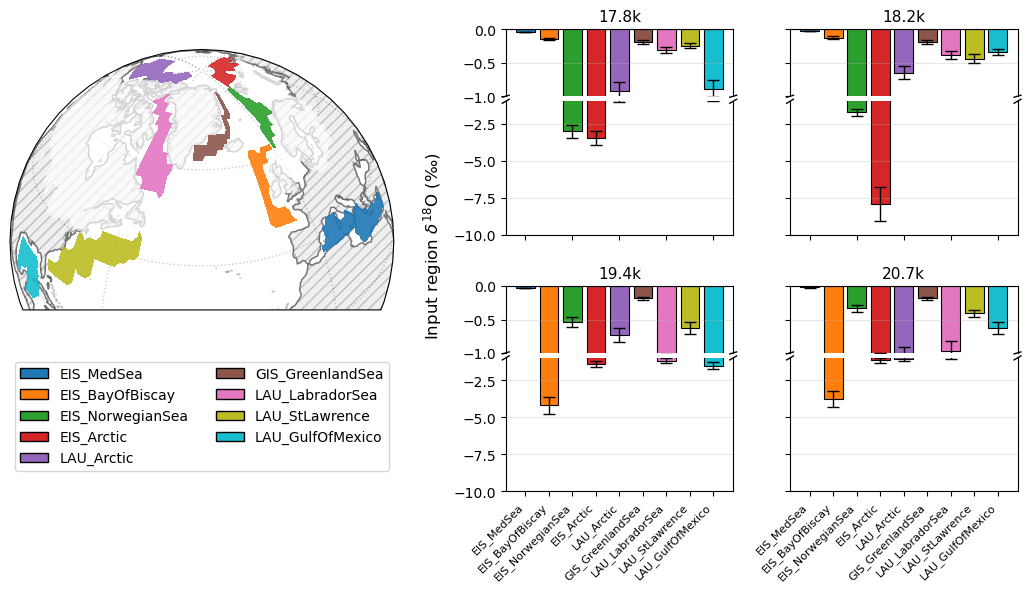

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.gridspec import GridSpecFromSubplotSpec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Patch


# --------------------------------------------------
# SETTINGS
# --------------------------------------------------

scenarios = ["17.8k", "18.2k", "19.4k", "20.7k"]

region_names = DYE_TABLE["region"].tolist()

region_colors = {
    region: color
    for region, color in zip(
        region_names,
        [
            "tab:blue",
            "tab:orange",
            "tab:green",
            "tab:red",
            "tab:purple",
            "tab:brown",
            "tab:pink",
            "tab:olive",
            "tab:cyan",
        ],
    )
}


# --------------------------------------------------
# Convert dye contributions to regional sums
# --------------------------------------------------

def sum_regions(dye_dict):

    region_dict = {}

    for region in region_names:

        dyes = DYE_TABLE.loc[
            DYE_TABLE["region"] == region,
            "dye"
        ].values

        region_dict[region] = sum(
            dye_dict[d]
            for d in dyes
            if d in dye_dict
        )

    return region_dict



# ==================================================
# FIGURE LAYOUT
# ==================================================

fig = plt.figure(figsize=(13,6))

gs = gridspec.GridSpec(
    nrows=2,
    ncols=2,
    figure=fig,
    width_ratios=[1.2, 1.6],   # map | bars
    height_ratios=[1, 0.5], # plot | legend
    wspace=0.25,
    hspace=0.05
)


# ==================================================
# LEFT MAP
# ==================================================

projection_map = ccrs.NearsidePerspective(
    central_longitude=-35,
    central_latitude=45,
    satellite_height=11000000
)

axMap = fig.add_subplot(
    gs[0,0],
    projection=projection_map
)


eps = np.spacing(0.0)

for i,d in enumerate(dyen[1:]):

    axMap.contourf(
        lon_lsm,
        lat_lsm,
        ds_dye[d].clip(min=eps).isel(t=0,depth=0),
        transform=ccrs.PlateCarree(),
        levels=[0.1,1],
        colors=colores[f'{i}'],
        zorder=10,
        alpha=0.9
    )


# land hatch
land = cfeature.NaturalEarthFeature(
    'physical',
    'land',
    '50m',
    edgecolor='k',
    facecolor='none'
)

axMap.add_feature(
    land,
    facecolor='#CCCCCC',
    hatch='///',
    edgecolor='0.3',
    zorder=2,
    alpha=0.3
)


axMap.coastlines(alpha=0.5)

axMap.gridlines(
    crs=ccrs.PlateCarree(),
    linewidth=1,
    color='black',
    alpha=0.2,
    linestyle=':',
    draw_labels=False
)


# optional shapefile
gdf_lgm = gdf_lgm.to_crs(projection_map.proj4_init)

gdf_lgm.plot(
    ax=axMap,
    facecolor='#FFFFFF',
    alpha=0.7,
    zorder=4
)


# ==================================================
# RIGHT: BROKEN AXIS BAR PLOTS
# ==================================================

# --------------------------------------------------
# Extract values
# --------------------------------------------------

bar_values = {}
lower_values = {}
upper_values = {}


for scen in scenarios:

    bar_values[scen] = sum_regions(
        lookup[scen]['-35.0 d18O']
    )

    lower_values[scen] = sum_regions(
        lookup[scen]['-40.0 d18O']
    )

    upper_values[scen] = sum_regions(
        lookup[scen]['-30.0 d18O']
    )



bar_outer = GridSpecFromSubplotSpec(
    2,
    2,
    subplot_spec=gs[0:2,1],
    wspace=0.25,
    hspace=0.25
)


for k, scen in enumerate(scenarios):

    inner = GridSpecFromSubplotSpec(
        2,
        1,
        subplot_spec=bar_outer[k],
        height_ratios=[1,2],
        hspace=0.05
    )

    ax_top = fig.add_subplot(inner[0])
    ax_bot = fig.add_subplot(inner[1], sharex=ax_top)


    regions = region_names

    values = np.array(
        [bar_values[scen][r] for r in regions]
    )

    lower = np.array(
        [lower_values[scen][r] for r in regions]
    )

    upper = np.array(
        [upper_values[scen][r] for r in regions]
    )


    x = np.arange(len(regions))

    yerr = np.vstack([
        values-lower,
        upper-values
    ])


    for ax in [ax_top, ax_bot]:

        ax.bar(
            x,
            values,
            color=[region_colors[r] for r in regions],
            edgecolor="black",
            linewidth=0.8
        )

        ax.errorbar(
            x,
            values,
            yerr=yerr,
            fmt="none",
            ecolor="black",
            capsize=4,
            linewidth=1
        )

        ax.axhline(
            0,
            color="grey",
            linewidth=0.8
        )

        ax.grid(
            axis="y",
            alpha=0.3
        )


    # --------------------------
    # broken axis limits
    # --------------------------

    ax_top.set_ylim(-1, 0)
    ax_bot.set_ylim(-10, -1)


    ax_top.spines["bottom"].set_visible(False)
    ax_bot.spines["top"].set_visible(False)

    ax_top.tick_params(
        labelbottom=False,
        bottom=False
    )


    if k < 2:
        ax_bot.tick_params(
            labelbottom=False
        )
    else:
        ax_bot.set_xticks(x)
        ax_bot.set_xticklabels(
            regions,
            rotation=45,
            ha="right",
            fontsize=8
        )


    if k % 2 == 1:
        ax_top.tick_params(labelleft=False)
        ax_bot.tick_params(labelleft=False)


    ax_top.set_title(
        scen,
        fontsize=11
    )


    # break marks
    d = 0.015

    kwargs=dict(
        color="k",
        clip_on=False,
        linewidth=1
    )

    ax_top.plot(
        (-d,d),
        (-d,d),
        transform=ax_top.transAxes,
        **kwargs
    )

    ax_top.plot(
        (1-d,1+d),
        (-d,d),
        transform=ax_top.transAxes,
        **kwargs
    )

    ax_bot.plot(
        (-d,d),
        (1-d,1+d),
        transform=ax_bot.transAxes,
        **kwargs
    )

    ax_bot.plot(
        (1-d,1+d),
        (1-d,1+d),
        transform=ax_bot.transAxes,
        **kwargs
    )



# ==================================================
# LEGEND BELOW BOTH PANELS
# ==================================================

ax_leg = fig.add_subplot(gs[1,0])
ax_leg.axis("off")


legend_handles = [
    Patch(
        facecolor=region_colors[r],
        edgecolor="black",
        label=r
    )
    for r in region_names
]


ax_leg.legend(
    handles=legend_handles,
    loc="center",
    ncol=2,
    frameon=True,
    fontsize=10
)


fig.text(
    0.45,          # x position: move this to align with left edge of bar block
    0.52,          # y position: center vertically over bars
    r"Input region $\delta^{18}$O (‰)",
    rotation=90,
    va="center",
    ha="center",
    fontsize=12,
)


# Save the Figure
plt.savefig(
    "my_output/chapter-four_latestfigures/Fig2_Rev_DyeRegions.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=300,
)


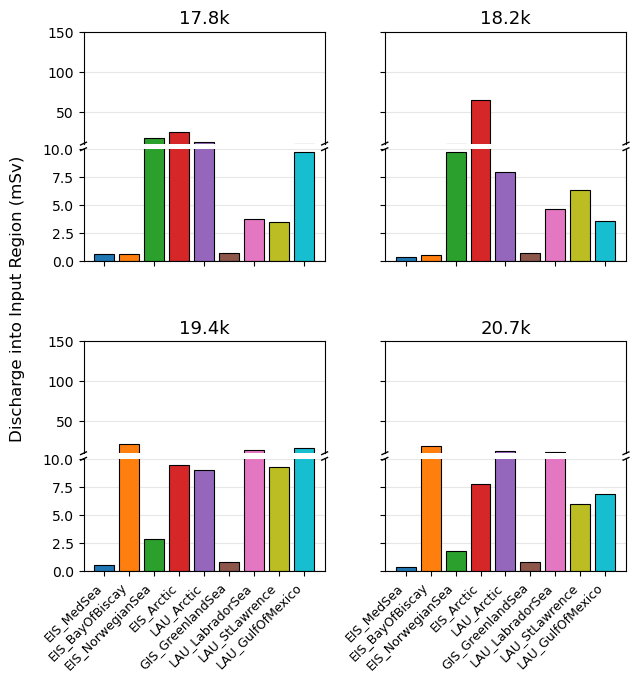

In [8]:
# Discharge Values not d18O

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

# --------------------------------------------------
# SETTINGS
# --------------------------------------------------

scenarios = ["17.8k", "18.2k", "19.4k", "20.7k"]

region_names = DYE_TABLE["region"].tolist()

region_colors = {
    region: color
    for region, color in zip(
        region_names,
        [
            "tab:blue",
            "tab:orange",
            "tab:green",
            "tab:red",
            "tab:purple",
            "tab:brown",
            "tab:pink",
            "tab:olive",
            "tab:cyan",
        ],
    )
}


# --------------------------------------------------
# Convert dye contributions to regional sums
# --------------------------------------------------

def sum_regions(dye_dict):

    region_dict = {}

    for region in region_names:

        dyes = DYE_TABLE.loc[
            DYE_TABLE["region"] == region,
            "dye"
        ].values

        region_dict[region] = sum(
            dye_dict[d]
            for d in dyes
            if d in dye_dict
        )

    return region_dict


# --------------------------------------------------
# Extract values
# --------------------------------------------------

bar_values = {}


for scen in scenarios:

    bar_values[scen] = sum_regions(
        lookup_dis[scen]
    )



# --------------------------------------------------
# FIGURE
# --------------------------------------------------

fig = plt.figure(figsize=(7, 7))

outer = GridSpec(
    2,
    2,
    figure=fig,
    wspace=0.25,
    hspace=0.35,
)

for k, scen in enumerate(scenarios):

    # nested gridspec for broken axis
    inner = GridSpecFromSubplotSpec(
        2,
        1,
        subplot_spec=outer[k],
        height_ratios=[1, 1],
        hspace=0.05,
    )

    ax_top = fig.add_subplot(inner[0])
    ax_bot = fig.add_subplot(inner[1], sharex=ax_top)

    regions = region_names

    values = np.array([bar_values[scen][r] for r in regions])


    x = np.arange(len(regions))

    yerr = np.vstack([
        values - lower,
        upper - values,
    ])

    # --------------------------
    # draw identical plots
    # --------------------------

    for ax in (ax_top, ax_bot):

        ax.bar(
            x,
            values*1000,
            color=[region_colors[r] for r in regions],
            edgecolor="black",
            linewidth=0.8,
            zorder=2,
        )

      

        ax.grid(axis="y", alpha=0.3)

        ax.axhline(
            0,
            color="grey",
            linewidth=0.8,
            zorder=1,
        )

    # --------------------------
    # broken axis limits
    # --------------------------

    ax_top.set_ylim(10, 150)
    ax_bot.set_ylim(0,10)

    # --------------------------
    # cosmetics
    # --------------------------

    ax_top.spines["bottom"].set_visible(False)
    ax_bot.spines["top"].set_visible(False)

    ax_top.tick_params(
        labelbottom=False,
        bottom=False,
    )

    # only bottom row gets x labels
    if k < 2:
        ax_bot.tick_params(labelbottom=False)
    else:
        ax_bot.set_xticks(x)
        ax_bot.set_xticklabels(
            regions,
            rotation=45,
            ha="right",
            fontsize=9,
        )

    # only left column gets y labels
    if k % 2 == 1:
        ax_top.tick_params(labelleft=False)
        ax_bot.tick_params(labelleft=False)

    # title
    ax_top.set_title(
        scen,
        fontsize=13,
        pad=6,
    )

    # --------------------------
    # break marks
    # --------------------------

    d = 0.012

    kwargs = dict(
        transform=ax_top.transAxes,
        color="k",
        clip_on=False,
        linewidth=1,
    )

    ax_top.plot((-d, +d), (-d, +d), **kwargs)
    ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)

    kwargs["transform"] = ax_bot.transAxes

    ax_bot.plot((-d, +d), (1 - d, 1 + d), **kwargs)
    ax_bot.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)


# --------------------------------------------------
# Common labels
# --------------------------------------------------

fig.supylabel(
    "Discharge into Input Region (mSv)",
    fontsize=12,
)

# Save the Figure
plt.savefig(
    "my_output/chapter-four_latestfigures/Fig2_Rev_Supp_Discharge.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=300,
)


